          KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CHÍNH: XGBOOST
► Độ chính xác tổng thể (Accuracy): 69.87%

► Báo cáo chi tiết hiệu năng theo từng cấp độ rượu:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.71      0.80      0.75        96
           6       0.69      0.66      0.67        99
           7       0.69      0.69      0.69        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.42       229
weighted avg       0.68      0.70      0.69       229



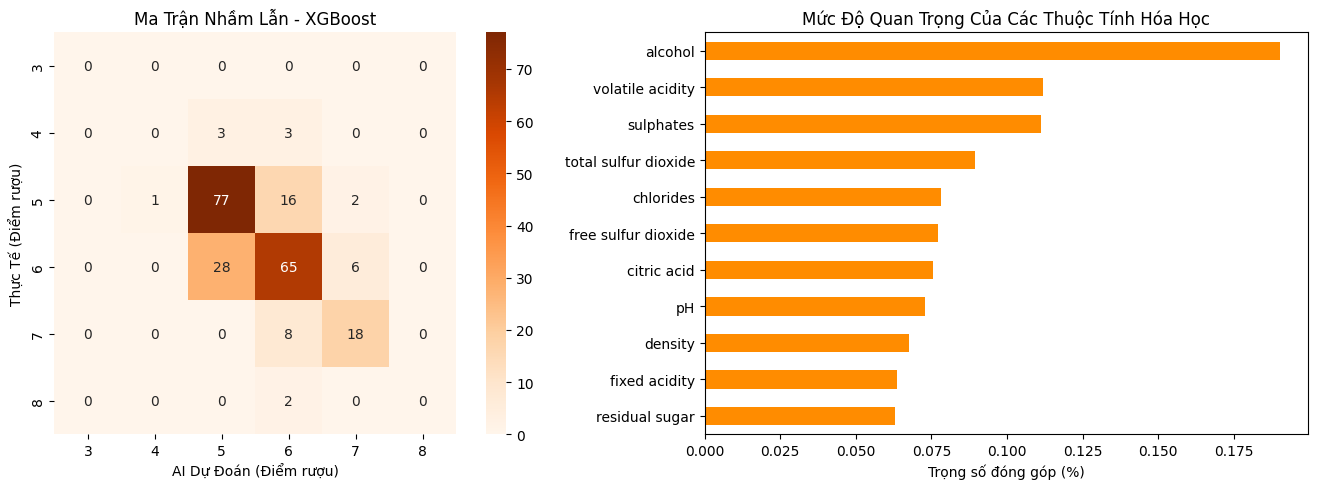

In [4]:
# ==========================================
# THƯ VIỆN HỆ THỐNG
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# ==========================================
# BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU ĐẶC THÙ CHO XGBOOST
# ==========================================
# Đọc file dữ liệu thực tế
df = pd.read_csv('E:\\project AI\\WineQT.csv')

# Phân tách Đề bài (X) và Đáp án (y)
X = df.drop(columns=['quality'])
y = df['quality']

# Khắc phục đặc tính của XGBoost: Ép nhãn điểm từ [3->8] về dạng [0->5]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Chia tập dữ liệu 80% Train / 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# ==========================================
# BƯỚC 2: XÂY DỰNG & HUẤN LUYỆN MÔ HÌNH XGBOOST
# ==========================================
xgb_model = XGBClassifier(
    n_estimators=100,       # Số lượng cây quyết định
    learning_rate=0.1,      # Tốc độ học
    random_state=42,        # Cố định ngẫu nhiên
    eval_metric='mlogloss'  # Thước đo sai số cho bài toán nhiều nhãn
)

# Cho mô hình bắt đầu học
xgb_model.fit(X_train, y_train)

# ==========================================
# BƯỚC 3: ĐÁNH GIÁ KẾT QUẢ THỰC TẾ
# ==========================================
# Mô hình tiến hành làm bài thi (dự đoán)
y_pred_encoded = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_encoded)

print("="*60)
print("          KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CHÍNH: XGBOOST")
print("="*60)
print(f"► Độ chính xác tổng thể (Accuracy): {accuracy * 100:.2f}%\n")

# BƯỚC QUAN TRỌNG: Dịch ngược nhãn từ [0->5] về lại [3->8] để người dùng đọc hiểu
y_test_real = label_encoder.inverse_transform(y_test)
y_pred_real = label_encoder.inverse_transform(y_pred_encoded)

print("► Báo cáo chi tiết hiệu năng theo từng cấp độ rượu:")
print(classification_report(y_test_real, y_pred_real, zero_division=0))
print("="*60)

# ==========================================
# BƯỚC 4: TRỰC QUAN HÓA BÁO CÁO (ĐỒ THỊ)
# ==========================================
plt.figure(figsize=(14, 5))

# 4.1 Vẽ Ma trận nhầm lẫn với cùng thứ tự nhãn để không bị lệch trục
plt.subplot(1, 2, 1)
class_labels = label_encoder.classes_
cm = confusion_matrix(y_test_real, y_pred_real, labels=class_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_labels, 
            yticklabels=class_labels,
            square=True)
plt.title('Ma Trận Nhầm Lẫn - XGBoost')
plt.xlabel('AI Dự Đoán (Điểm rượu)')
plt.ylabel('Thực Tế (Điểm rượu)')

# 4.2 Vẽ biểu đồ Độ quan trọng của các thuộc tính hóa học
plt.subplot(1, 2, 2)
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='darkorange')
plt.title('Mức Độ Quan Trọng Của Các Thuộc Tính Hóa Học')
plt.xlabel('Trọng số đóng góp (%)')

# Căn chỉnh và hiển thị
plt.tight_layout()
plt.show()